# CliffWalking Q-Learning
Tabular Q-learning on the **CliffWalking-v0** Gymnasium environment.

## Environment Overview
| Property | Value |
|---|---|
| State space | 48 discrete states (4 × 12 grid) |
| Action space | 4 actions: up, down, left, right |
| Start | Bottom-left corner |
| Goal | Bottom-right corner (state 47) |
| Cliff | Bottom row between start and goal — large penalty + episode reset |

The agent learns to navigate from start to goal while **avoiding the cliff** using Q-learning with an ε-greedy exploration policy.

## Install & Import Dependencies

In [7]:
# Install gymnasium if not already present
!pip install gymnasium matplotlib seaborn numpy imageio

In [15]:
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio
import numpy as np
import random
import seaborn as sn
import matplotlib.pyplot as plt
from IPython.display import Image
import imageio.v2 as imageio
import numpy as np

## Q-Learning Background

After observing a transition $(s_t, a_t, r_{t+1}, s_{t+1})$, the update rule is:

$$Q(s_t, a_t) \leftarrow (1 - \alpha)\, Q(s_t, a_t) + \alpha \Big( r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') \Big)$$

- **α** (learning rate): how much new information overrides old estimates  
- **γ** (discount factor): importance of future rewards  
- **ε-greedy**: explore randomly with probability ε, otherwise exploit the best known action  
- **ε decays** over time so the agent explores early and exploits later

## Hyperparameters

In [9]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
LEARNING_RATE   = 0.1      # α  — step size for Q updates
DISCOUNT_FACTOR = 0.95     # γ  — weight of future rewards
EPSILON         = 1.0      # starting exploration rate
EPSILON_DECAY   = 0.9995   # multiplicative decay per episode
EPSILON_MIN     = 0.01     # floor for ε
N_EPISODES      = 10000   # total training episodes
MAX_STEPS       = 50       # max steps per episode
GOAL_STATE      = 47       # terminal goal state index in CliffWalking-v0

print("Hyperparameters set.")

Hyperparameters set.


## Q-Table Initialisation

The CliffWalking environment already has a **discrete** state space (48 states), so no discretisation is needed.  
The Q-table is a `(48, 4)` NumPy array initialised with small random values.

In [11]:
env = gym.make("CliffWalking-v1")
env.reset()

# 48 states × 4 actions
q_table = np.random.uniform(low=0, high=1, size=(48, 4))

print(f"Q-table shape: {q_table.shape}")
print(f"State  space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Q-table shape: (48, 4)
State  space: Discrete(48)
Action space: Discrete(4)


## Training Loop

For each episode:
1. Reset the environment.
2. Choose an action via **ε-greedy** policy.
3. Observe the new state and reward.
4. Apply the **Q-learning update**.
5. Decay ε after the episode ends.

In [12]:
epsilon = EPSILON
reward_list: list[float] = []

for episode in range(N_EPISODES):
    step = 0
    state = env.reset()[0]
    done = False
    total_reward = 0.0

    while not done and step < MAX_STEPS:
        # ε-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()          # explore
        else:
            action = int(np.argmax(q_table[state]))     # exploit

        new_state, reward, done, _, _ = env.step(action)
        total_reward += reward

        if not done:
            # Standard Q-learning update
            best_future_q = np.max(q_table[new_state])
            current_q     = q_table[state][action]
            new_q = (1 - LEARNING_RATE) * current_q + LEARNING_RATE * (
                reward + DISCOUNT_FACTOR * best_future_q
            )
            q_table[state][action] = new_q

        elif new_state == GOAL_STATE:
            q_table[state][action] = 0          # terminal state — no future reward
            done = True
            print(f"  ✓ Goal reached — episode {episode:>5d}, step {step}")

        step  += 1
        state  = new_state

    reward_list.append(total_reward)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

env.close()
print(f"\nTraining complete. Final ε = {epsilon:.4f}")

  ✓ Goal reached — episode   202, step 24
  ✓ Goal reached — episode   315, step 48
  ✓ Goal reached — episode   414, step 40
  ✓ Goal reached — episode   458, step 35
  ✓ Goal reached — episode   464, step 30
  ✓ Goal reached — episode   486, step 46
  ✓ Goal reached — episode   510, step 42
  ✓ Goal reached — episode   517, step 49
  ✓ Goal reached — episode   524, step 41
  ✓ Goal reached — episode   547, step 45
  ✓ Goal reached — episode   553, step 24
  ✓ Goal reached — episode   626, step 25
  ✓ Goal reached — episode   634, step 39
  ✓ Goal reached — episode   660, step 41
  ✓ Goal reached — episode   666, step 43
  ✓ Goal reached — episode   673, step 33
  ✓ Goal reached — episode   676, step 31
  ✓ Goal reached — episode   679, step 25
  ✓ Goal reached — episode   692, step 48
  ✓ Goal reached — episode   693, step 31
  ✓ Goal reached — episode   694, step 43
  ✓ Goal reached — episode   696, step 38
  ✓ Goal reached — episode   702, step 49
  ✓ Goal reached — episode   708, 

## Reward Curve
Plotting total reward per episode shows how the agent improves over time.

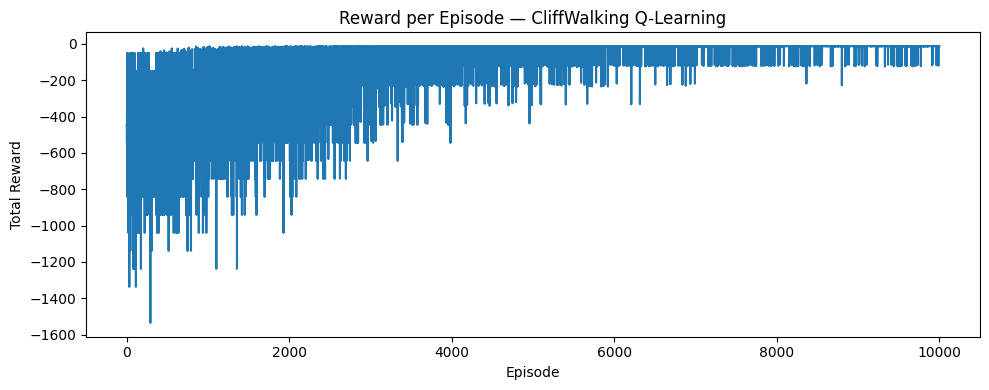

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
sn.lineplot(reward_list, ax=ax)
ax.set_title("Reward per Episode — CliffWalking Q-Learning")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
plt.tight_layout()
plt.show()

## Evaluation — Greedy Policy

After training, run one episode with **ε = 0** (pure exploitation) and the render window enabled.  
The agent should navigate cleanly from start to goal without falling off the cliff.

Evaluation episode total reward: -13.0


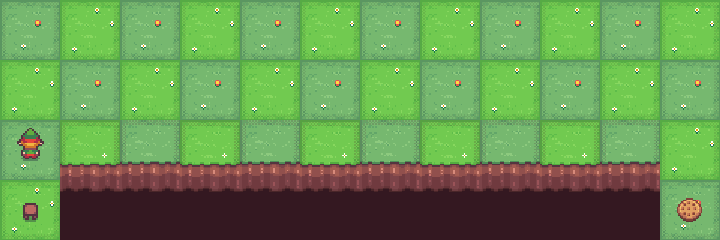

In [17]:
eval_env = gym.make("CliffWalking-v1", render_mode="rgb_array")
state = eval_env.reset()[0]
done  = False
total_eval_reward = 0.0
frames=[]
while not done:
    action = int(np.argmax(q_table[state]))
    state, reward, done, _, _ = eval_env.step(action)
    total_eval_reward += reward
    frames.append(eval_env.render())

eval_env.close()
print(f"Evaluation episode total reward: {total_eval_reward}")

# Save the frames as a GIF

imageio.mimsave("cliff_walking_q_learning.gif", frames, fps=10)
Image("cliff_walking_q_learning.gif")

## Summary

| Item | Detail |
|---|---|
| Algorithm | Tabular Q-learning (off-policy) |
| Exploration | ε-greedy with exponential decay |
| State space | Discrete — no discretisation needed |
| Episodes | 10 000 |
| Key challenge | Avoiding the cliff while finding a short path to the goal |

**Next steps:** try SARSA (on-policy) — it tends to take the *longer* but *safer* upper path because it accounts for the risk of accidentally stepping off the cliff during exploration.